In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import time


In [2]:
dataset = pd.read_csv("Final_cleaned_realestate_houseprice.csv")

In [3]:
dataset.head()

,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,0.529749,0.904293,1.045104,0.962274,-0.030941,-0.764210,1.266330,1,0,-1.187943,40275084.00
1,-0.170338,-0.437056,0.161028,0.331502,-0.846958,-0.284951,0.375105,1,0,0.828587,26812029.00
2,0.695871,0.233618,0.161028,0.088897,-1.173365,0.366349,0.778754,0,0,0.208116,29315677.00
3,1.660397,0.904293,0.161028,1.010795,-0.928560,-1.255758,0.196594,1,1,-0.567472,46250249.55
4,-0.275436,-0.437056,0.161028,-0.881522,-0.683755,0.722721,-0.436855,0,0,1.138822,17724566.00


In [4]:
# data
X = dataset["area_sqft"].values
y = dataset["house_price_inr"].values

# normalization
X = (X - X.mean()) / X.std()

n = len(X)

In [5]:
batch_size = 32

w = 0
b = 0

learning_rate = 0.01
epochs = 50

cost_history_mini = []

start = time.time()

In [6]:
for epoch in range(epochs):

    for i in range(0, n, batch_size):

        X_batch = X[i:i+batch_size]
        y_batch = y[i:i+batch_size]

        y_pred = w * X_batch + b

        dw = (-2/len(X_batch)) * np.sum(X_batch * (y_batch - y_pred))
        db = (-2/len(X_batch)) * np.sum(y_batch - y_pred)

        w = w - learning_rate * dw
        b = b - learning_rate * db

    y_pred_all = w * X + b
    cost = np.mean((y - y_pred_all)**2)

    cost_history_mini.append(cost)

end = time.time()

mini_time = end - start

print("Mini Batch slope:", w)
print("Mini Batch intercept:", b)
print("Training Time:", mini_time)

Mini Batch slope: 8611142.961927338
Mini Batch intercept: 23303454.469738577
Training Time: 0.25974202156066895


In [7]:
y_pred_mini = w * X + b

result_mini = pd.DataFrame({
    "Actual Price": y,
    "Predicted Price": y_pred_mini
})

print(result_mini.head(10))

   Actual Price  Predicted Price
0   40275084.00     2.786520e+07
1   26812029.00     2.183665e+07
2   29315677.00     2.929570e+07
3   46250249.55     3.760137e+07
4   17724566.00     2.093164e+07
5   26448337.00     2.093164e+07
6   44768109.00     3.812686e+07
7   30291804.00     3.043426e+07
8   16161989.00     1.869830e+07
9   12273622.00     2.830311e+07


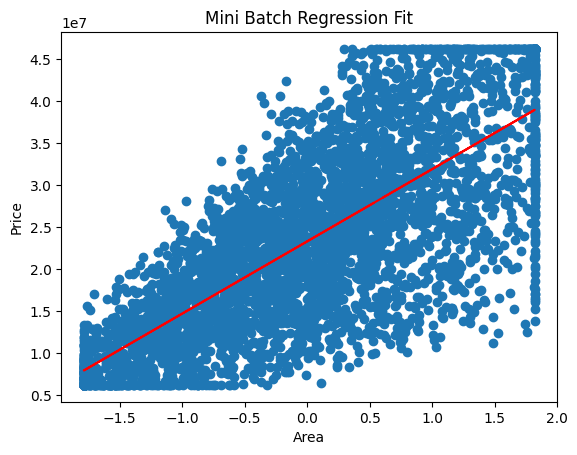

In [8]:
plt.scatter(X, y)

plt.plot(X, y_pred_mini, color="red")

plt.title("Mini Batch Regression Fit")

plt.xlabel("Area")
plt.ylabel("Price")

plt.show()

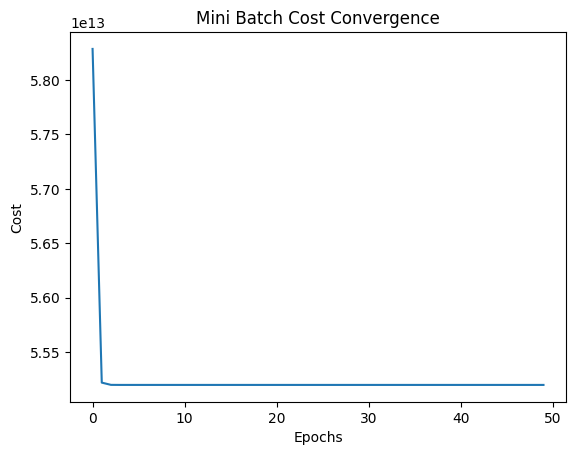

In [9]:
plt.plot(cost_history_mini)

plt.title("Mini Batch Cost Convergence")

plt.xlabel("Epochs")
plt.ylabel("Cost")

plt.show()

In [10]:
mse = mean_squared_error(y,y_pred_mini)
print(f"Mean squared error : {mse}")

Mean squared error : 55196232842998.89


In [11]:
mae = mean_absolute_error(y,y_pred_mini)
print(f"Mean absolute error : {mae}")

Mean absolute error : 5880839.7442563195


In [12]:
rmse = np.sqrt(mse)
print(f"root mean sqaured error : {rmse}")

root mean sqaured error : 7429416.72293316


In [13]:
r2 = r2_score(y,y_pred_mini)
print(f"R2 score : {r2}")

R2 score : 0.5689205993744857


In [14]:
accurate_percentage_ = r2 * 100
print(f"Accurate Percentage : {accurate_percentage_}%")

Accurate Percentage : 56.89205993744857%


In [15]:
# Number of samples and predictors
n = len(y)
p = 1   # simple regression has 1 predictor

Adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f"Adjusted r2 score : {Adjusted_r2}")

Adjusted r2 score : 0.5688179125234554
